In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import os

import sys

sys.path.insert(0, "../../Modules")

from utils import process_greek, create_grid

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thrace'
NUTS2_ID = 'EL51'
NUTS1_COLNAME = 'NUTS1_ID'
NUTS2_COLNAME = 'NUTS2_ID'

In [4]:
shapefile_gdf = gpd.read_file(f"../../Europe Shapefiles/Greece/data/EL_Whole.shp",  encoding=enc)

In [5]:
shapefile_gdf.head()

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL301,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL302,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL303,Kentrikos Tomeas Athinon,Κεντρικός Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL304,Notios Tomeas Athinon,Νότιος Τομέας Αθηνών,4.0,1,1,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL305,Anatoliki Attiki,Ανατολική Αττική,2.0,1,1,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [6]:
print(f'shapefile\'s CRS before conversion: {shapefile_gdf.crs}')
shapefile_gdf = shapefile_gdf.to_crs(epsg=4326)
print(f'shapefile\'s CRS after conversion: {shapefile_gdf.crs}')

shapefile's CRS before conversion: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
shapefile's CRS after conversion: EPSG:4326


In [7]:
shapefile_gdf[NUTS2_COLNAME].unique()

array(['EL30', 'EL41', 'EL42', 'EL43', 'EL51', 'EL52', 'EL53', 'EL54',
       'EL61', 'EL62', 'EL63', 'EL64', 'EL65'], dtype=object)

In [8]:
nuts3_gdf = shapefile_gdf.loc[shapefile_gdf[NUTS2_COLNAME] == f'{NUTS2_ID}'].copy()
nuts3_gdf.head()

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
16,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL51,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",EL511,Evros,Έβρος,4.0,2,1,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."
17,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL51,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",EL512,Xanthi,Ξάνθη,2.0,2,1,"POLYGON ((25.17938 41.31019, 25.17954 41.30251..."
18,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL51,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",EL513,Rodopi,Ροδόπη,2.0,3,1,"POLYGON ((25.90644 41.30757, 25.92568 41.27678..."
19,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL51,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",EL514,Drama,Δράμα,2.0,2,2,"POLYGON ((24.78396 41.36019, 24.77851 41.35909..."
20,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL51,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",EL515,"Thasos, Kavala","Θάσος, Καβάλα",3.0,3,1,"MULTIPOLYGON (((24.81349 40.85809, 24.80609 40..."


<Axes: >

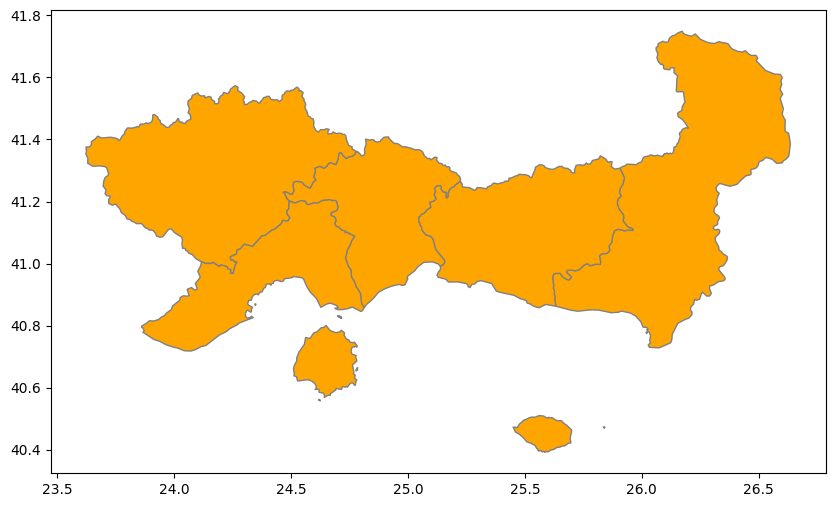

In [9]:
nuts3_gdf.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [10]:
nuts2_gdf = nuts3_gdf.dissolve(by = NUTS1_COLNAME, as_index = False)

<Axes: >

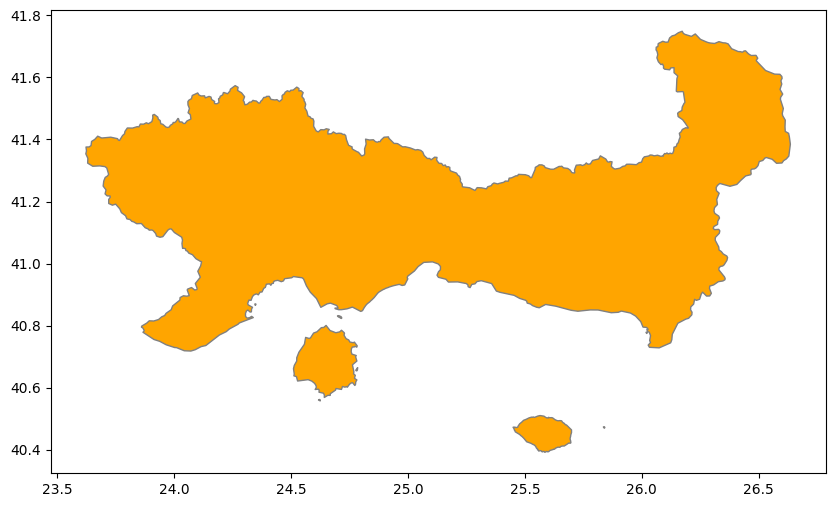

In [11]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [12]:
nuts2_gdf = nuts2_gdf[['NUTS2_ID', 'NUTS2_NAME', 'geometry']]
nuts2_gdf.reset_index(inplace=True, drop = True)

In [13]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, nuts2_gdf, col_municipal=NUTS2_COLNAME, dimension=2)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

In [14]:
df_grid.shape

(3266, 5)

In [15]:
df_grid.head()

,geometry,centers,NUTS2_ID,x,y
0,"POLYGON ((23.67061 41.32644, 23.67061 41.34440...",POINT (23.658819828962606 41.33541930901127),EL51,23.65882,41.33542
1,"POLYGON ((23.67061 41.34440, 23.67061 41.36237...",POINT (23.658819828962606 41.35338600061149),EL51,23.65882,41.35339
2,"POLYGON ((23.67061 41.36237, 23.67061 41.38034...",POINT (23.658819828962606 41.3713526922117),EL51,23.65882,41.37135
3,"POLYGON ((23.69420 41.32644, 23.69420 41.34440...",POINT (23.682409714937673 41.33541930901127),EL51,23.68241,41.33542
4,"POLYGON ((23.69420 41.34440, 23.69420 41.36237...",POINT (23.682409714937673 41.35338600061149),EL51,23.68241,41.35339


<Axes: >

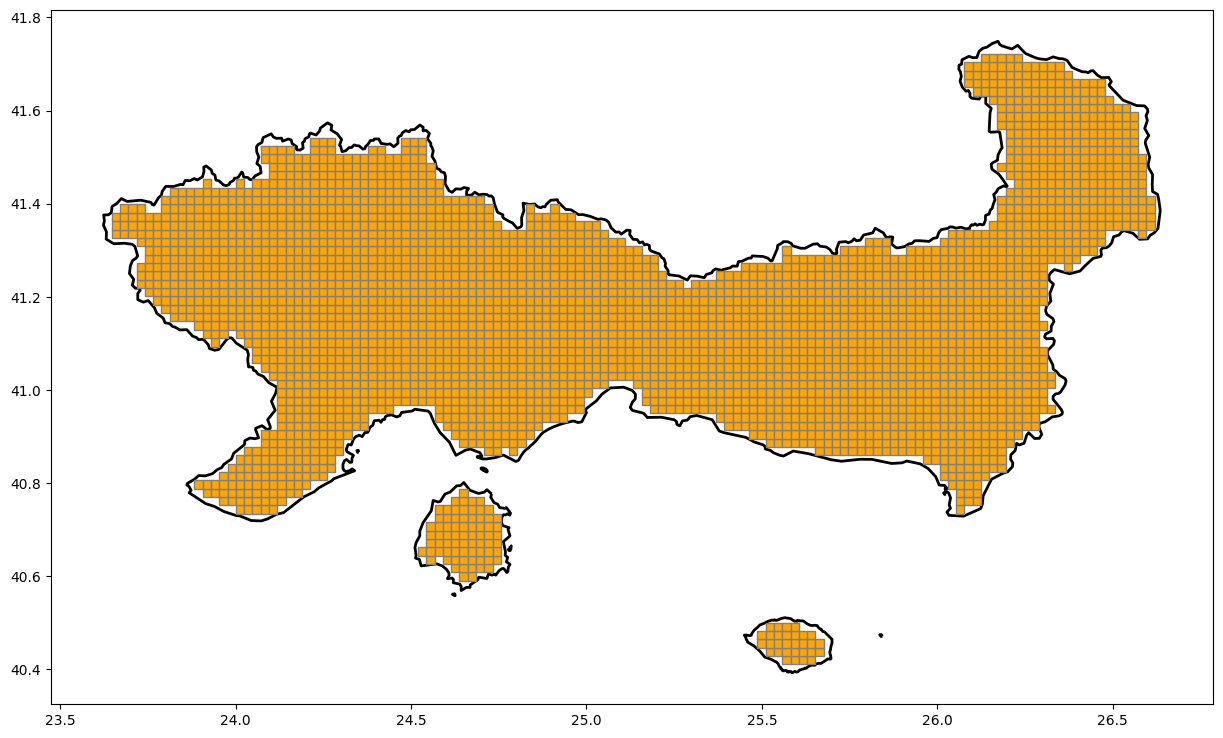

In [16]:
ax = nuts2_gdf.plot(figsize=(15, 15), facecolor="none", edgecolor='black', lw=2)
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [17]:
df_grid.set_geometry('centers', inplace=True)

In [18]:
gdf_merged = gpd.sjoin(df_grid, nuts3_gdf, how='left', op='within')
gdf_merged.set_geometry('geometry', inplace=True)

<Axes: >

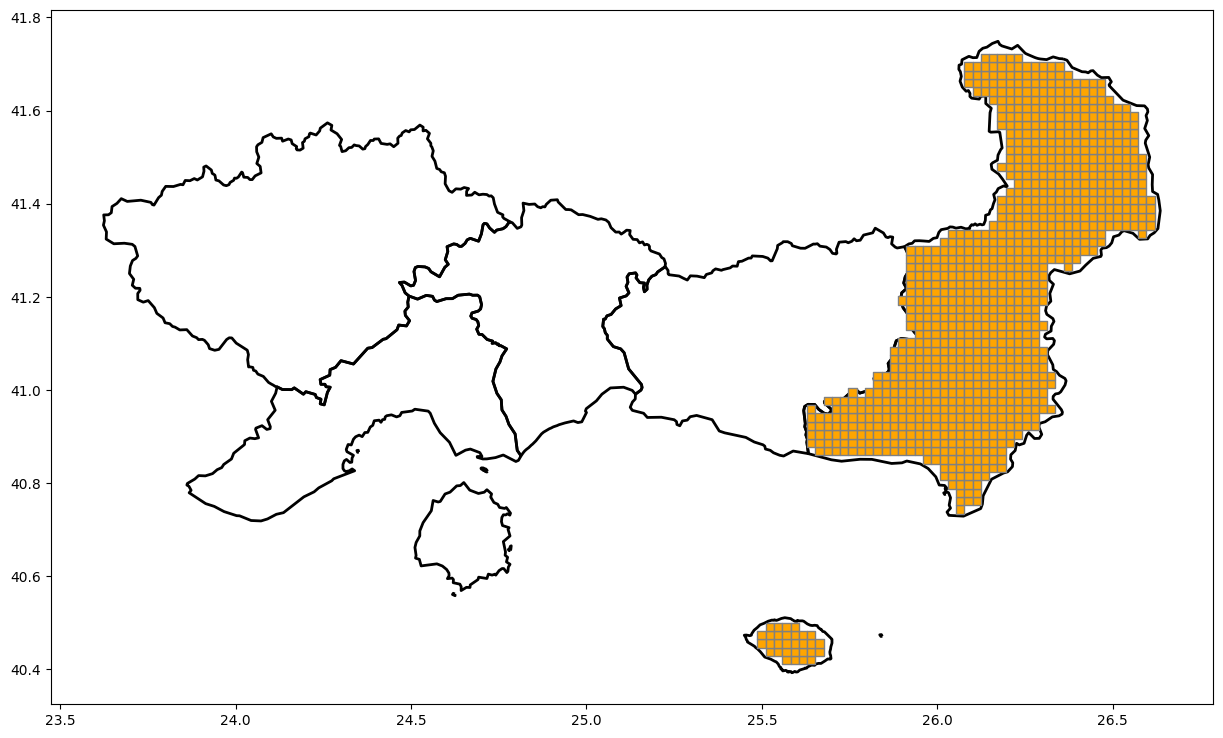

In [19]:
ax = nuts3_gdf.plot(figsize=(15, 15), facecolor="none", edgecolor='black', lw=2)
gdf_merged[gdf_merged['NUTS3_ID'] == 'EL511'].plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [20]:
gdf_merged.head()

,geometry,centers,NUTS2_ID_left,x,y,index_right,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID_right,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,"POLYGON ((23.67061 41.32644, 23.67061 41.34440...",POINT (23.65882 41.33542),EL51,23.65882,41.33542,19,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL51,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",EL514,Drama,Δράμα,2.0,2,2
1,"POLYGON ((23.67061 41.34440, 23.67061 41.36237...",POINT (23.65882 41.35339),EL51,23.65882,41.35339,19,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL51,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",EL514,Drama,Δράμα,2.0,2,2
2,"POLYGON ((23.67061 41.36237, 23.67061 41.38034...",POINT (23.65882 41.37135),EL51,23.65882,41.37135,19,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL51,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",EL514,Drama,Δράμα,2.0,2,2
3,"POLYGON ((23.69420 41.32644, 23.69420 41.34440...",POINT (23.68241 41.33542),EL51,23.68241,41.33542,19,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL51,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",EL514,Drama,Δράμα,2.0,2,2
4,"POLYGON ((23.69420 41.34440, 23.69420 41.36237...",POINT (23.68241 41.35339),EL51,23.68241,41.35339,19,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL51,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",EL514,Drama,Δράμα,2.0,2,2


In [21]:
final_grid = gdf_merged[['NUTS2_ID_left', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y', 'geometry']]
final_grid.set_geometry('geometry', inplace=True)
final_grid.rename(columns={'NUTS2_ID_left': "NUTS2_ID"}, inplace=True)
final_grid.sort_values(by=['NUTS3_ID', 'x', 'y'], inplace = True)
final_grid.reset_index(drop=True, inplace=True)

In [22]:
final_grid['cell_code'] = final_grid['NUTS3_ID'] + pd.Series(final_grid.index + 1).apply(lambda x: f"{x:06d}")
process_greek(final_grid, 'NUTS3_NAME')
process_greek(final_grid, 'NUTS2_NAME')

In [23]:
final_grid = final_grid[['NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y', 'cell_code', 'geometry']]

In [24]:
final_grid.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,cell_code,geometry
0,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,25.49883,40.45505,EL511000001,"POLYGON ((25.51063 40.44607, 25.51063 40.46403..."
1,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,25.49883,40.47302,EL511000002,"POLYGON ((25.51063 40.46403, 25.51063 40.48200..."
2,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,25.52242,40.43708,EL511000003,"POLYGON ((25.53422 40.42810, 25.53422 40.44607..."
3,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,25.52242,40.45505,EL511000004,"POLYGON ((25.53422 40.44607, 25.53422 40.46403..."
4,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,25.52242,40.47302,EL511000005,"POLYGON ((25.53422 40.46403, 25.53422 40.48200..."


In [25]:
final_grid.drop(columns='geometry').to_csv(f'../data/GR_{NUTS2}_Grid.csv', encoding=enc, index = False)
final_grid.to_file(f'../data/GR_{NUTS2}_Grid.shp', encoding = 'utf-8')